In [16]:
import yfinance as yf

import pandas as pd

tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'TSLA']
start = "2010-01-01"
end = "2024-12-31"

price_data = yf.download(tickers, start=start, end=end, interval='1mo')['Close'].dropna()
returns = price_data.pct_change().dropna()


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  7 of 7 completed


In [17]:
returns

Ticker,AAPL,AMZN,GOOGL,META,MSFT,NVDA,TSLA
Date,,,,,,,
2012-06-01,0.010853,0.072519,-0.001360,0.050676,0.054838,0.111826,0.060678
2012-07-01,0.045822,0.021677,0.091196,-0.301929,-0.036613,-0.020260,-0.123682
2012-08-01,0.089200,0.064166,0.082342,-0.168125,0.045809,0.036189,0.040117
2012-09-01,0.007102,0.024369,0.101315,0.199336,-0.027996,-0.049180,0.026648
2012-10-01,-0.107600,-0.084264,-0.098343,-0.025392,-0.040995,-0.101949,-0.039276
...,...,...,...,...,...,...,...
2024-08-01,0.031160,-0.045352,-0.047569,0.097888,-0.002892,0.020082,-0.077390
2024-09-01,0.018645,0.043866,0.015118,0.098080,0.033407,0.017341,0.221942
2024-10-01,-0.030429,0.000376,0.033085,-0.007544,-0.055659,0.093308,-0.045025


In [18]:
import yfinance as yf
import pandas as pd
import numpy as np
from fredapi import Fred
from tqdm import tqdm

# Replace with your real API key
fred = Fred(api_key='7330ed2e4fa58187a98a1551febb9e76')

In [19]:
features_list = []

for ticker in tqdm(tickers):
    df = pd.DataFrame(index=returns.index)
    r = returns[ticker]

    df['momentum_12m'] = r.rolling(12).apply(lambda x: np.prod(1 + x[-11:-1]) - 1)
    df['volatility_3m'] = r.rolling(3).std()
    df['short_term_reversal'] = -r.shift(1)
    df['past_return'] = r.shift(1)
    
    df['stock'] = ticker
    df['target_return'] = r.shift(-1)  # next month return as target
    features_list.append(df)

features = pd.concat(features_list)
features.reset_index(inplace=True)


100%|█████████████████████████████████████████████| 7/7 [00:00<00:00, 46.94it/s]


In [20]:
macro_vars = {
    'DTB3': 'tbill_3m',        # 3-month Treasury Bill
    'T10Y2Y': 'term_spread',   # Term spread
    'VIXCLS': 'vix'            # Market volatility index
}

macro_df = pd.DataFrame(index=features['Date'].unique())
for code, name in macro_vars.items():
    macro_df[name] = fred.get_series(code).reindex(macro_df.index).ffill()

macro_df.index = pd.to_datetime(macro_df.index)
features = features.merge(macro_df, how='left', left_on='Date', right_index=True)


In [21]:
for feat in ['momentum_12m', 'volatility_3m']:
    for macro in ['tbill_3m', 'term_spread', 'vix']:
        features[f'{feat}*{macro}'] = features[feat] * features[macro]


In [22]:
sector_map = {}
for ticker in tickers:
    info = yf.Ticker(ticker).info
    sector_map[ticker] = info.get("sector", "Unknown")

features['sector'] = features['stock'].map(sector_map)
sector_dummies = pd.get_dummies(features['sector'], prefix='sector')
features = pd.concat([features, sector_dummies], axis=1)


In [23]:
final_data = features.drop(columns=['stock', 'sector'])
final_data.dropna(inplace=True)


In [28]:
final_data.sort_values(['Date'], inplace=True)
final_data.describe()

,Date,momentum_12m,volatility_3m,short_term_reversal,past_return,target_return,tbill_3m,term_spread,vix,momentum_12m*tbill_3m,momentum_12m*term_spread,momentum_12m*vix,volatility_3m*tbill_3m,volatility_3m*term_spread,volatility_3m*vix
count,973,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,2019-01-30 20:22:26.762589952,0.383870,0.087084,-0.030902,0.030902,0.030247,1.478633,0.729712,17.323741,0.425345,0.366816,6.790656,0.135085,0.055534,1.604001
min,2013-05-01 00:00:00,-0.723027,0.000946,-0.810706,-0.367334,-0.367334,-0.020000,-0.880000,9.890000,-2.935488,-2.481828,-18.661317,-0.002864,-0.286686,0.013520
25%,2016-03-01 00:00:00,0.066073,0.042927,-0.081950,-0.033089,-0.032764,0.050000,0.170000,13.250000,0.003646,0.002436,1.139007,0.003656,0.006213,0.657776
50%,2019-02-01 00:00:00,0.255804,0.071562,-0.022776,0.022776,0.022543,0.500000,0.630000,15.390000,0.042059,0.157696,3.826360,0.029855,0.039112,1.139097
75%,2022-01-01 00:00:00,0.465930,0.109109,0.033089,0.081950,0.081950,2.270000,1.320000,19.630000,0.367464,0.432831,7.601287,0.174497,0.089753,1.941949
max,2024-11-01 00:00:00,6.911851,0.496276,0.367334,0.810706,0.741452,5.310000,2.390000,57.060000,15.033602,11.968696,198.732780,1.810448,0.810356,20.522011
std,NaN,0.714256,0.064105,0.110389,0.110389,0.107309,1.819356,0.859869,6.428130,1.525992,1.016316,15.936818,0.224434,0.097054,1.650712


In [25]:
final_data.to_csv("kelly_style_dataset.csv", index=False)

In [3]:
# common imports & data prep
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# load your CSV
df = pd.read_csv('kelly_style_dataset.csv', parse_dates=['Date'])
X = df.drop(columns=['Date','target_return']).values
y = df['target_return'].values

# train/test split (no shuffle for time series)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, shuffle=False, test_size=0.2
)

# scale
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

# torch tensors & loaders
device = 'cuda' if torch.cuda.is_available() else 'cpu'
train_ds = TensorDataset(
    torch.tensor(X_train_s,dtype=torch.float32),
    torch.tensor(y_train  ,dtype=torch.float32).unsqueeze(1)
)
test_ds  = TensorDataset(
    torch.tensor(X_test_s ,dtype=torch.float32),
    torch.tensor(y_test   ,dtype=torch.float32).unsqueeze(1)
)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds , batch_size=64, shuffle=False)


In [4]:
# pip install git+https://github.com/KindXiaoming/pykan.git
from kan import KAN   # after installing the repo into your environment

# build & train
model_kan = KAN([X_train_s.shape[1], 64, 32, 1], grid=5, k=3).to(device)
opt = torch.optim.Adam(model_kan.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for epoch in range(50):
    model_kan.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss_fn(model_kan(xb), yb).backward()
        opt.step()

# eval
model_kan.eval()
with torch.no_grad():
    pred_kan = model_kan(torch.tensor(X_test_s, dtype=torch.float32).to(device))
r2_kan = r2_score(y_test, pred_kan.cpu().numpy())
print("KAN  R²:", r2_kan)


checkpoint directory created: ./model
saving model version 0.0
KAN  R²: -4.1148663670409995


In [5]:
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import r2_score

# 1) make sure X_train_s is (n_samples, n_features)
print("X_train_s shape:", X_train_s.shape)  # e.g. (800, 16)

# 2) DataLoader
Xtr = torch.tensor(X_train_s, dtype=torch.float32)
ytr = torch.tensor(y_train,   dtype=torch.float32).unsqueeze(1)
train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=64, shuffle=True)

# 3) DNN class
class DNN(nn.Module):
    def __init__(self, dims):
        super().__init__()
        layers = []
        for i in range(len(dims)-2):
            layers += [ nn.Linear(dims[i], dims[i+1]), nn.ReLU() ]
        layers.append(nn.Linear(dims[-2], dims[-1]))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

# 4) instantiate with correct input dim
n_features = X_train_s.shape[1]
model_dnn = DNN([n_features, 128, 64, 1])
opt       = torch.optim.Adam(model_dnn.parameters(), lr=1e-3)
loss_fn   = nn.MSELoss()

# 5) training loop
for epoch in range(50):
    model_dnn.train()
    for xb, yb in train_loader:
        opt.zero_grad()
        loss_fn(model_dnn(xb), yb).backward()
        opt.step()

# 6) evaluation
model_dnn.eval()
Xte = torch.tensor(X_test_s, dtype=torch.float32)
with torch.no_grad():
    y_pred_dnn = model_dnn(Xte).numpy().flatten()

print("DNN R²:", r2_score(y_test, y_pred_dnn))


X_train_s shape: (778, 16)
DNN R²: -7.952663105114064


In [6]:
class SimpleRNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=32):
        super().__init__()
        self.rnn = nn.RNN(input_dim, hidden_dim, batch_first=True)
        self.out = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        # treat each sample as a sequence of length 1
        x = x.unsqueeze(1)  # (B,1,features)
        h,_ = self.rnn(x)
        return self.out(h[:, -1, :])

model_rnn = SimpleRNN(X_train_s.shape[1], hidden_dim=32).to(device)
opt = torch.optim.Adam(model_rnn.parameters(), lr=1e-3)

for epoch in range(50):
    model_rnn.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        nn.MSELoss()(model_rnn(xb), yb).backward()
        opt.step()

model_rnn.eval()
with torch.no_grad():
    pred_rnn = model_rnn(torch.tensor(X_test_s, dtype=torch.float32).to(device))
print("RNN  R²:", r2_score(y_test, pred_rnn.cpu().numpy()))


RNN  R²: -0.6797644971140906


In [7]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)
gbr.fit(X_train_s, y_train)
pred_gbr = gbr.predict(X_test_s)
print("GBRT R²:", r2_score(y_test, pred_gbr))


GBRT R²: -1.502952353987422


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics     import r2_score

# 1) Instantiate & fit
lr = LinearRegression()
lr.fit(X_train_s, y_train)

# 2) Predict on test set
y_pred_lr = lr.predict(X_test_s)

# 3) Compute R²
r2_lr = r2_score(y_test, y_pred_lr)
print("Linear Regression R²:", r2_lr)


Linear Regression R²: -0.3233518888974576


In [9]:
import pandas as pd
import numpy as np

# Load your full dataset (as written out by your feature engineering code)
df = pd.read_csv("kelly_style_dataset.csv", parse_dates=['Date'])

# Let’s say your test set is the last N rows (N = len(y_test) you used before)
N = len(y_test)    # Make sure this matches your earlier split!

test_df = df.iloc[-N:].copy().reset_index(drop=True)


In [10]:
test_df['pred_kan'] = pred_kan
test_df['pred_dnn'] = y_pred_dnn
test_df['pred_rnn'] = pred_rnn
test_df['pred_gbrt'] = pred_gbr
test_df['pred_lr'] = y_pred_lr


In [11]:
def assign_deciles(x):
    return pd.qcut(x, 10, labels=False, duplicates='drop')

for col in ['pred_kan', 'pred_dnn', 'pred_rnn', 'pred_gbrt', 'pred_lr']:
    test_df[f'decile_{col}'] = test_df.groupby('Date')[col].transform(assign_deciles)


In [12]:
ls_dict = {}
sharpe_dict = {}
for col in ['pred_kan', 'pred_dnn', 'pred_rnn', 'pred_gbrt', 'pred_lr']:
    ls_rets = []
    for dt, group in test_df.groupby('Date'):
        if group[f'decile_{col}'].max() == group[f'decile_{col}'].min():
            continue
        top = group[group[f'decile_{col}'] == group[f'decile_{col}'].max()]['target_return'].mean()
        bot = group[group[f'decile_{col}'] == group[f'decile_{col}'].min()]['target_return'].mean()
        ls_rets.append(top - bot)
    ls_rets = np.array(ls_rets)
    ls_dict[col] = ls_rets         # <-- save to dictionary!
    sharpe = ls_rets.mean() / ls_rets.std() * np.sqrt(12) if ls_rets.std() > 0 else np.nan
    sharpe_dict[col] = sharpe
    print(f"{col}: Monthly Long-Short Sharpe = {sharpe:.2f}")

pred_kan: Monthly Long-Short Sharpe = 0.02
pred_dnn: Monthly Long-Short Sharpe = -0.90
pred_rnn: Monthly Long-Short Sharpe = -0.92
pred_gbrt: Monthly Long-Short Sharpe = 0.74
pred_lr: Monthly Long-Short Sharpe = -0.63


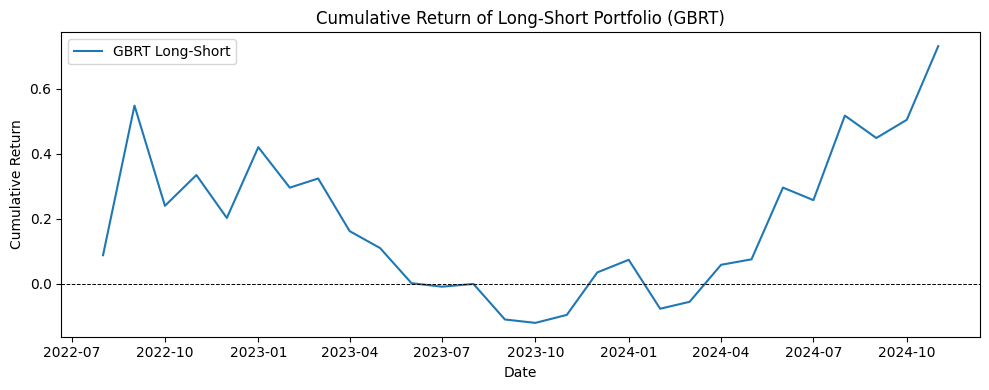

In [13]:
import matplotlib.pyplot as plt
import numpy as np

cumret_gbrt = np.cumprod(1 + ls_dict['pred_gbrt']) - 1
dates = test_df['Date'].unique()[:len(ls_dict['pred_gbrt'])]  # align to length of LS returns

plt.figure(figsize=(10,4))
plt.plot(dates, cumret_gbrt, label='GBRT Long-Short')
plt.axhline(0, ls='--', c='k', lw=0.7)
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Cumulative Return of Long-Short Portfolio (GBRT)')
plt.legend()
plt.tight_layout()
plt.show()

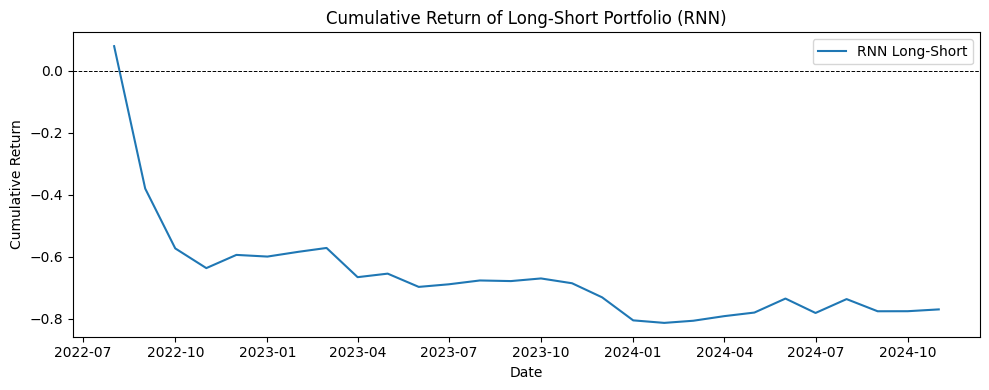

In [14]:
import matplotlib.pyplot as plt
import numpy as np

cumret_gbrt = np.cumprod(1 + ls_dict['pred_rnn']) - 1
dates = test_df['Date'].unique()[:len(ls_dict['pred_rnn'])]  # align to length of LS returns

plt.figure(figsize=(10,4))
plt.plot(dates, cumret_gbrt, label='RNN Long-Short')
plt.axhline(0, ls='--', c='k', lw=0.7)
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Cumulative Return of Long-Short Portfolio (RNN)')
plt.legend()
plt.tight_layout()
plt.show()

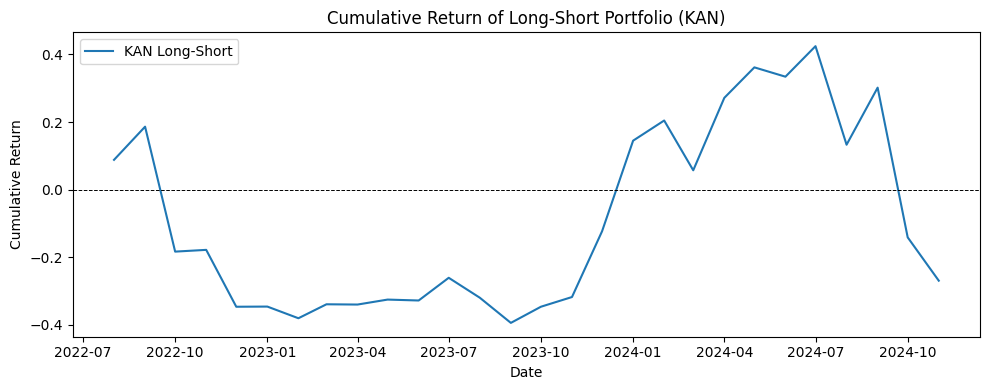

In [22]:
import matplotlib.pyplot as plt
import numpy as np

cumret_gbrt = np.cumprod(1 + ls_dict['pred_kan']) - 1
dates = test_df['Date'].unique()[:len(ls_dict['pred_kan'])]  # align to length of LS returns

plt.figure(figsize=(10,4))
plt.plot(dates, cumret_gbrt, label='KAN Long-Short')
plt.axhline(0, ls='--', c='k', lw=0.7)
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Cumulative Return of Long-Short Portfolio (KAN)')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
import numpy as np

def max_drawdown(returns):
    # Calculate cumulative returns (assuming monthly returns, as before)
    cum_returns = np.cumprod(1 + returns)
    # Compute running max
    running_max = np.maximum.accumulate(cum_returns)
    # Drawdown is the percentage drop from peak
    drawdown = (cum_returns - running_max) / running_max
    # Return the minimum (most negative) drawdown
    return drawdown.min()

# Example: Calculate for all models and display
for model in ls_dict.keys():
    dd = max_drawdown(ls_dict[model])
    print(f"{model}: Max Drawdown = {dd:.2%}")


pred_kan: Max Drawdown = -48.91%
pred_dnn: Max Drawdown = -89.34%
pred_rnn: Max Drawdown = -82.71%
pred_gbrt: Max Drawdown = -43.17%
pred_lr: Max Drawdown = -85.39%


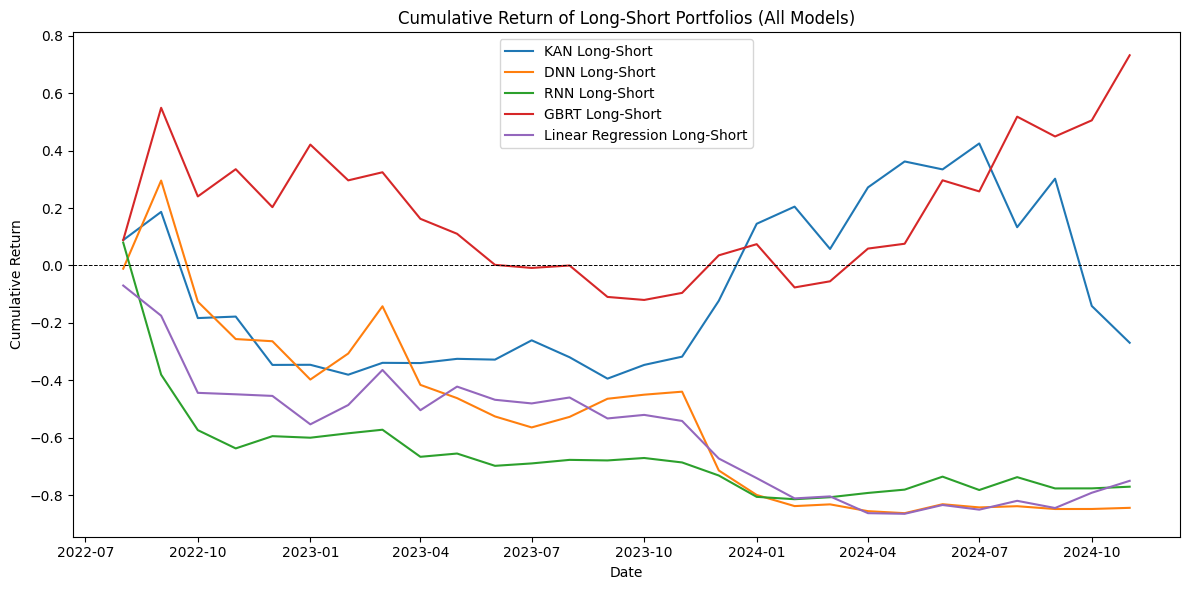

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Models to include (update keys to match your ls_dict)
model_names = ['pred_kan', 'pred_dnn', 'pred_rnn', 'pred_gbrt', 'pred_lr']
display_names = {
    'pred_kan': 'KAN',
    'pred_dnn': 'DNN',
    'pred_rnn': 'RNN',
    'pred_gbrt': 'GBRT',
    'pred_lr': 'Linear Regression'
}

dates = test_df['Date'].unique()  

plt.figure(figsize=(12,6))

for m in model_names:
    ls_rets = ls_dict[m]
    # Align dates to LS array length, if needed
    plot_dates = dates[:len(ls_rets)]
    cumret = np.cumprod(1 + np.array(ls_rets)) - 1
    plt.plot(plot_dates, cumret, label=f'{display_names[m]} Long-Short')

plt.axhline(0, ls='--', c='k', lw=0.7)
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Cumulative Return of Long-Short Portfolios (All Models)')
plt.legend()
plt.tight_layout()
plt.show()
